In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
from generation_info import GenerationInfoHandler

/local/home/prisold/gidd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data

base_dir = "/local/home/prisold/gidd/outputs/generation_info"
num_dirs = len([name for name in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, name))]) # to use all combinations
# num_dirs = 2 # to use first n combinations
combination_row_ids = [i for i in range(1, num_dirs)] # if combination_0 also exists
# combination_row_ids = [i for i in range(num_dirs)] # if combination_0 does not exist
# combination_row_ids = [0] # to use combination_0

dir_path_dict = {}
meta_dict = {}
history_dict = {}
marginals_dict = {}
change_events_table_dict = {}
denoise_config_dict = {}
combination_rows = []

for combination_row in combination_row_ids:
    dir_path = f"{base_dir}/combination_{combination_row}"
    meta, history, marginals, change_events_table = GenerationInfoHandler.load_all(dir_path)
    dir_path_dict[combination_row] = dir_path
    meta_dict[combination_row] = meta
    history_dict[combination_row] = history
    marginals_dict[combination_row] = marginals
    change_events_table_dict[combination_row] = change_events_table
    denoise_config_dict[combination_row] = meta['sampling']['p_denoise']

    sampling_parameters = meta['sampling'].copy()
    if isinstance(sampling_parameters.get('p_denoise', None), dict):
        for k, v in sampling_parameters['p_denoise'].items():
            sampling_parameters[f'p_denoise_{k}'] = v
        del sampling_parameters['p_denoise']
    sampling_parameters['combination_row'] = combination_row
    combination_rows.append(sampling_parameters)

combinations_df = pd.DataFrame(combination_rows)

print(meta_dict[combination_row_ids[0]])

{'created_at': '2025-09-03 15:45:06 GMT', 'num_samples': 64, 'max_seq_len': 81, 'collect_history': True, 'collect_marginals': True, 'collect_change_events': True, 'sampling': {'strategy': 'gidd_prob_to_recover_data', 'score_mask_position': None, 'score_position_for_change': None, 'select_position': None, 'select_position_change': None, 'select_position_unmask': None, 'change_token': None, 'unmask_token': None, 'k': None, 'gumbel_noise_coefficient': None, 'self_correction': 'none', 'p_denoise': {'oracle': 'perfect', 'position_sampling': 'independent', 'position_metric': 'p_denoise', 'token_sampling': 'categorical', 'uniform_noise': 'none'}}, 'history_shape': [64, 84, 81], 'marginals_shapes': {'true_denoised_fraction': [82], 'denoised_fraction': [82], 'mask_fraction': [82], 'uniform_fraction': [82], 'p_zt_x_mean': [64, 82], 'p_zt_x_std': [64, 82], 'p_zt_x_min': [64, 82], 'p_zt_x_max': [64, 82], 'cell_accuracy': [64, 82], 'expected_cell_accuracy': [82], 'total_accuracy': [82]}}


In [3]:
# Select combination to analyze

# oracle = 'perfect'
oracle = 'model'
# oracle = 'recurrence'
# oracle = 'model_and_recurrence'
# oracle = 'model_EMA'

# position_sampling = 'independent'
position_sampling = 'top_k'

position_metric = 'p_denoise'
# position_metric = 'confident_and_p_denoise'
# position_metric = 'confident_and_noisy'

# token_sampling = 'categorical'
token_sampling = 'change_max'
# token_sampling = 'max'

uniform_noise = 'none'
# uniform_noise = 'noise'
# uniform_noise = 'model'

combination_row = combinations_df.loc[(combinations_df['p_denoise_oracle'] == oracle) & (combinations_df['p_denoise_position_sampling'] == position_sampling) & (combinations_df['p_denoise_position_metric'] == position_metric) & (combinations_df['p_denoise_token_sampling'] == token_sampling) & (combinations_df['p_denoise_uniform_noise'] == uniform_noise)]['combination_row'].item()
print(f"selected combination row: {combination_row}")

selected combination row: 35


In [6]:
# Plot total accuracy
skip = True
if not skip:
    fig, ax = plt.subplots(figsize=(10, 6))

    for combination_row in combination_row_ids:
        marginals = marginals_dict[combination_row]
        total_accuracy = marginals['total_accuracy'].cpu().numpy()  # shape (num_denoising_steps,)
        label = ', '.join([f'{key}={value}' for key, value in denoise_config_dict[combination_row].items()])
        ax.plot(total_accuracy, label=label)

    ax.set_xlabel('Timestep')
    ax.set_ylabel('Total Accuracy')
    ax.set_title('Total Accuracy Over Time')
    ax.legend()
    plt.tight_layout()


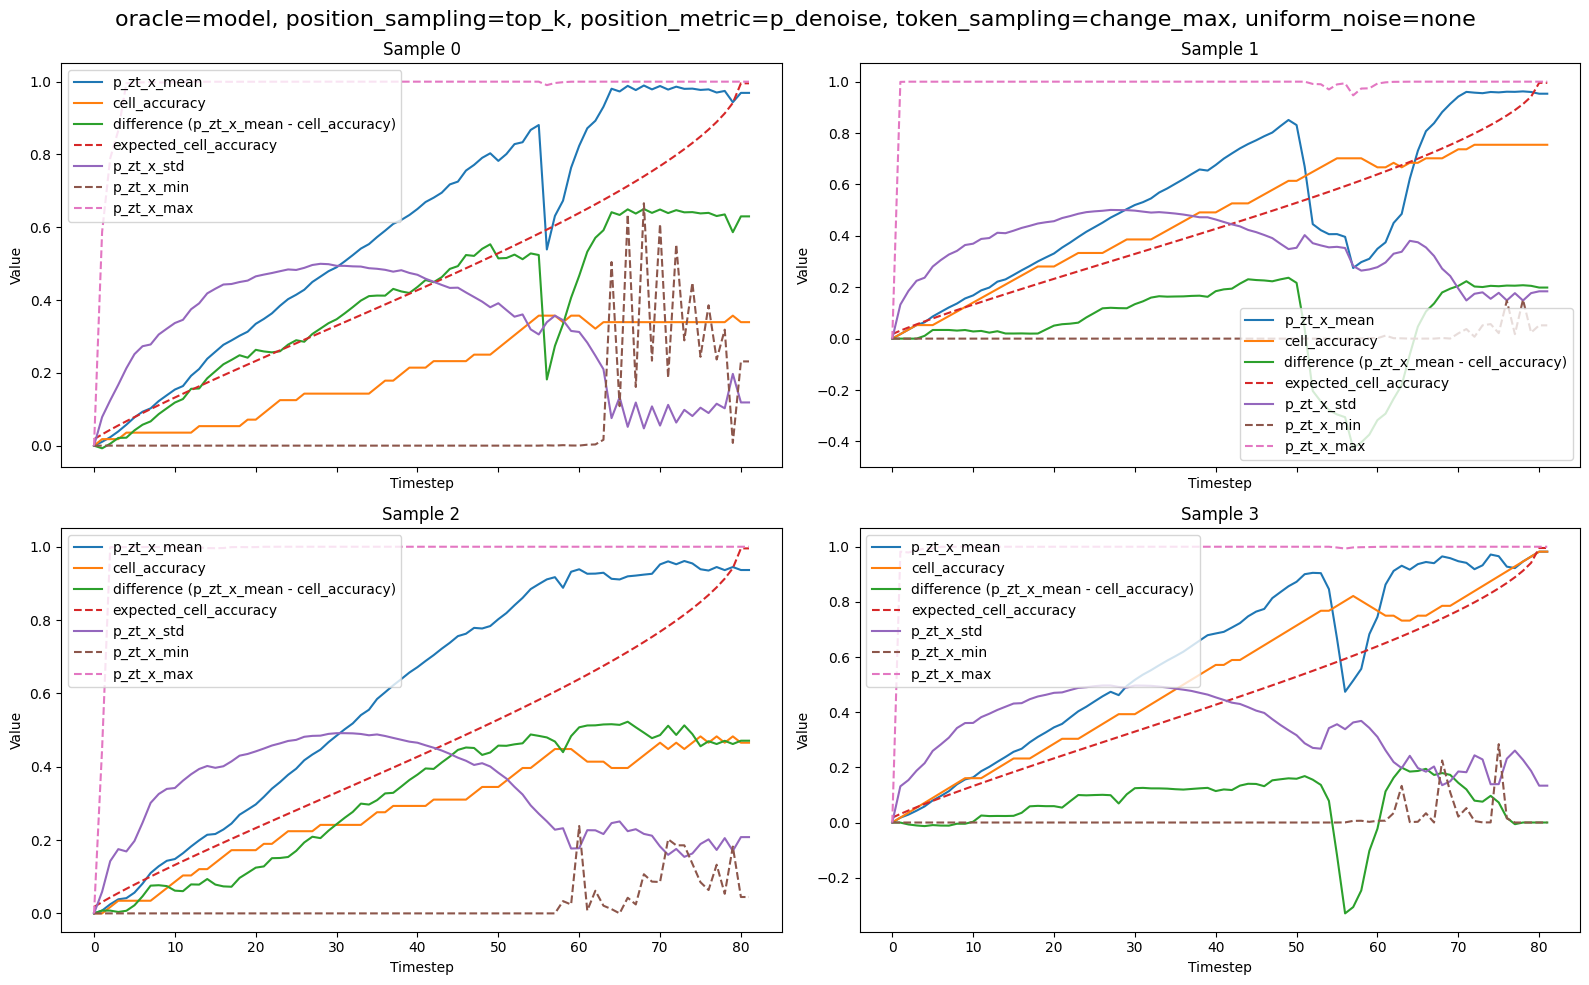

In [4]:
# Plot marginals
marginals = marginals_dict[combination_row]
p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()  # shape: (num_samples, num_steps)
p_zt_x_std = marginals['p_zt_x_std'].cpu().numpy()    # shape: (num_samples, num_steps)
p_zt_x_min = marginals['p_zt_x_min'].cpu().numpy()    # shape: (num_samples, num_steps)
p_zt_x_max = marginals['p_zt_x_max'].cpu().numpy()    # shape: (num_samples, num_steps)
cell_accuracy = marginals['cell_accuracy'].cpu().numpy()  # shape: (num_samples, num_steps)
expected_cell_accuracy = marginals['expected_cell_accuracy'].cpu().numpy()  # shape: (num_steps)
difference = p_zt_x_mean - cell_accuracy

fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
sample_indices = [0, 1, 2, 3]
# sample_indices = [49,57,59,60]
for ax, idx in zip(axs.flatten(), sample_indices):
    ax.plot(p_zt_x_mean[idx], label='p_zt_x_mean')
    ax.plot(cell_accuracy[idx], label='cell_accuracy')
    ax.plot(difference[idx], label='difference (p_zt_x_mean - cell_accuracy)')
    ax.plot(expected_cell_accuracy, label='expected_cell_accuracy', linestyle='--')
    ax.plot(p_zt_x_std[idx], label='p_zt_x_std')
    ax.plot(p_zt_x_min[idx], label='p_zt_x_min', linestyle='--')
    ax.plot(p_zt_x_max[idx], label='p_zt_x_max', linestyle='--')
    ax.set_title(f'Sample {idx}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()
plt.suptitle(', '.join([f'{key}={value}' for key, value in denoise_config_dict[combination_row].items()]), fontsize=16)
plt.tight_layout()

plt.savefig(dir_path_dict[combination_row] + '/marginals.png')

[46  0 25  6 52 14  7 17 19 40  2 22 32 39 37 27 29 34 16 26 55 23 41 11
 42  5  8 20 50 56 61 15 38  4 24 33 13 48 53 47 57  1 28 30 54  3 10  9
 31 21 18 12 35 45 43 36 44 51 49 58 59 60 62 63]
Sample 0, cell accuracy at last step: 0.3392857015132904 (step 81)
Sample 1, cell accuracy at last step: 0.7543859481811523 (step 81)
Sample 2, cell accuracy at last step: 0.4655172526836395 (step 81)
Sample 3, cell accuracy at last step: 0.9821428656578064 (step 81)


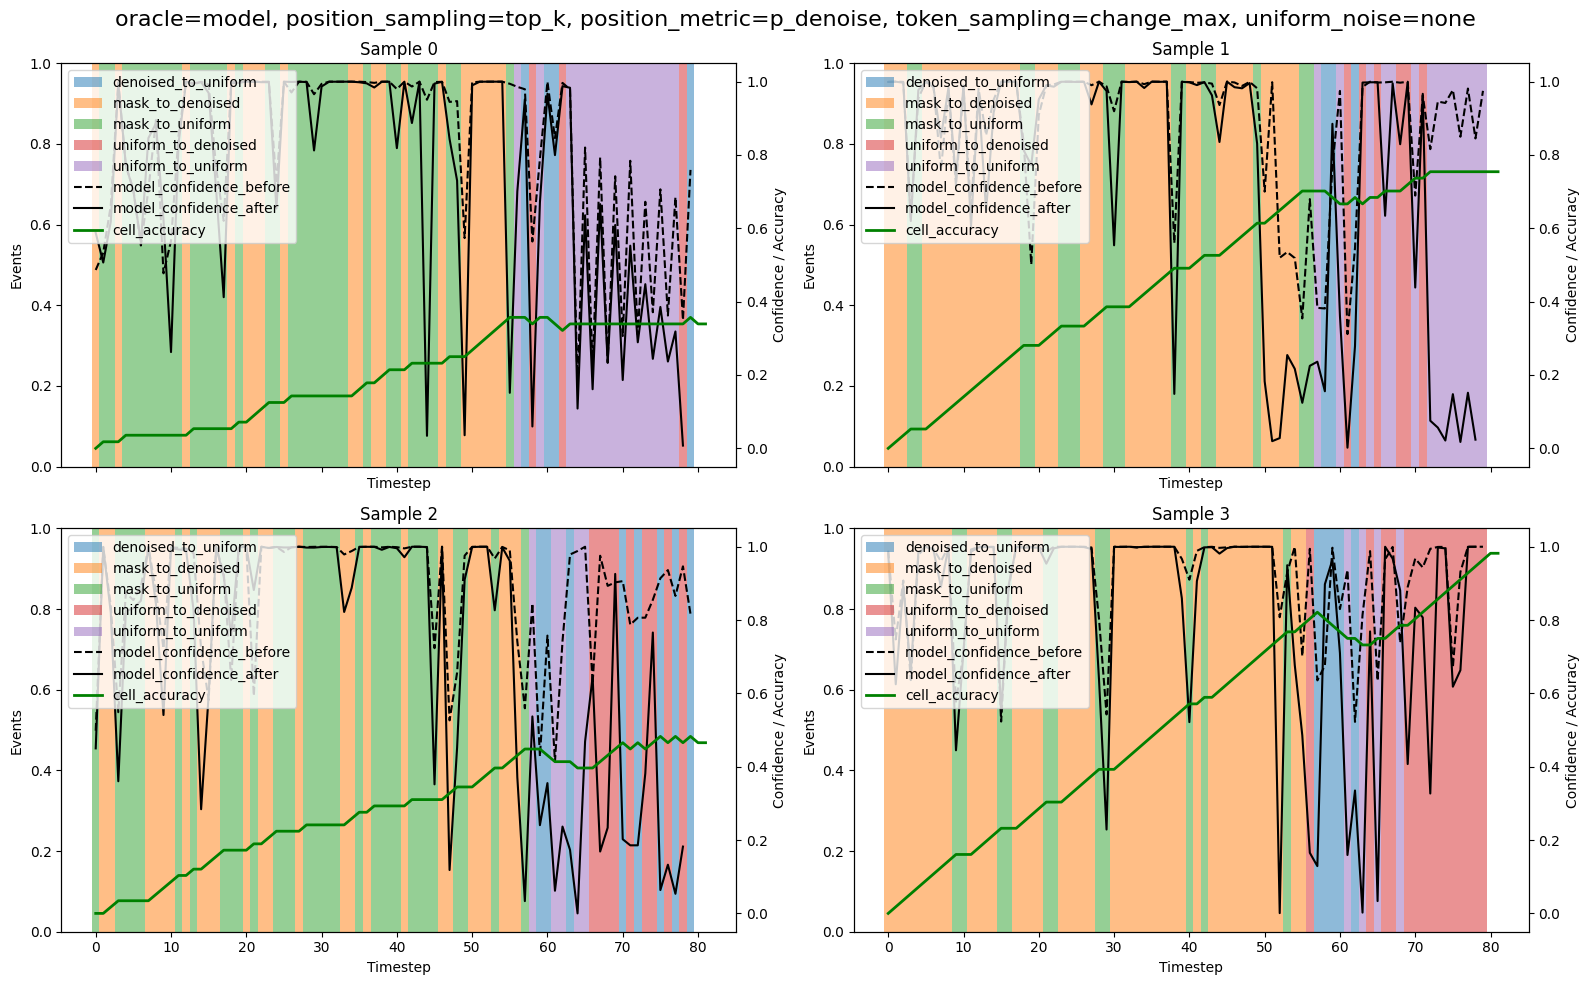

In [5]:
# Plot change events #TODO: add mean confidence to plot
change_events_table = change_events_table_dict[combination_row]
marginals = marginals_dict[combination_row]
cell_accuracy = marginals['cell_accuracy'].cpu().numpy()
indices = cell_accuracy[:, -1].argsort()  # Indices that would sort the array
print(indices)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
sample_indices = [0, 1, 2, 3]
# sample_indices = [49,57,59,60]
for ax, idx in zip(axs.flatten(), sample_indices):
    # Filter change events for the current sample
    sample_events = change_events_table[change_events_table['sample'] == idx]

    # Plot number of events per step, colored by event_type
    event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)
    # Don't use the built-in bar plot which creates categorical axes
    # event_counts.plot(ax=ax, kind='bar', stacked=True, width=1, alpha=0.5, legend=False)
    # Instead, plot bars manually using the actual step values as x-coordinates
    bottom = None
    for event_type in event_counts.columns:
        ax.bar(event_counts.index, event_counts[event_type], bottom=bottom, 
               alpha=0.5, width=1, label=event_type)
        if bottom is None:
            bottom = event_counts[event_type]
        else:
            bottom += event_counts[event_type]

    # Create a secondary y-axis for confidence and accuracy
    ax2 = ax.twinx()

    # Plot model_confidence before and after update per step
    mean_conf_before = sample_events.groupby('step')['model_confidence'].mean()
    ax2.plot(mean_conf_before.index, mean_conf_before.values, color='black', label='model_confidence_before', linestyle='--')
    mean_conf_after = sample_events.groupby('step')['model_confidence_after'].mean()
    ax2.plot(mean_conf_after.index, mean_conf_after.values, color='black', label='model_confidence_after')

    # Plot cell_accuracy for this sample - now using actual timestep indices
    timesteps = range(len(cell_accuracy[idx]))
    ax2.plot(timesteps, cell_accuracy[idx], color='green', label='cell_accuracy', linewidth=2)
    print(f"Sample {idx}, cell accuracy at last step: {cell_accuracy[idx, -1]} (step {len(cell_accuracy[idx]) - 1})")

    ax.set_title(f'Sample {idx}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Events')
    ax2.set_ylabel('Confidence / Accuracy')

    # Combine legends from both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.suptitle(', '.join([f'{key}={value}' for key, value in denoise_config_dict[combination_row].items()]), fontsize=16)
plt.tight_layout()

plt.savefig(dir_path_dict[combination_row] + '/change_events.png')

In [ ]:
# Select combinations to compare

oracles = [
    # "perfect",
    "model",
    # "recurrence",
    # "model_and_recurrence",
    "model_EMA"
    ]
position_sampling_strategies = [
    "independent",
    "top_k"
]
position_metric_strategies = [
    "p_denoise",
    # "confident_and_p_denoise",
    # "confident_and_noisy"
]
token_sampling_strategies = [
    # "categorical",
    "change_max",
    # "max"
]
uniform_noise_strategies = [
    "none",
    # "noise",
    # "model"
]

selected_combinations = combinations_df.loc[(combinations_df['p_denoise_oracle'].isin(oracles)) & (combinations_df['p_denoise_position_sampling'].isin(position_sampling_strategies)) & (combinations_df['p_denoise_position_metric'].isin(position_metric_strategies)) & (combinations_df['p_denoise_token_sampling'].isin(token_sampling_strategies)) & (combinations_df['p_denoise_uniform_noise'].isin(uniform_noise_strategies))]['combination_row'].tolist()
num_selected_combinations = len(selected_combinations)

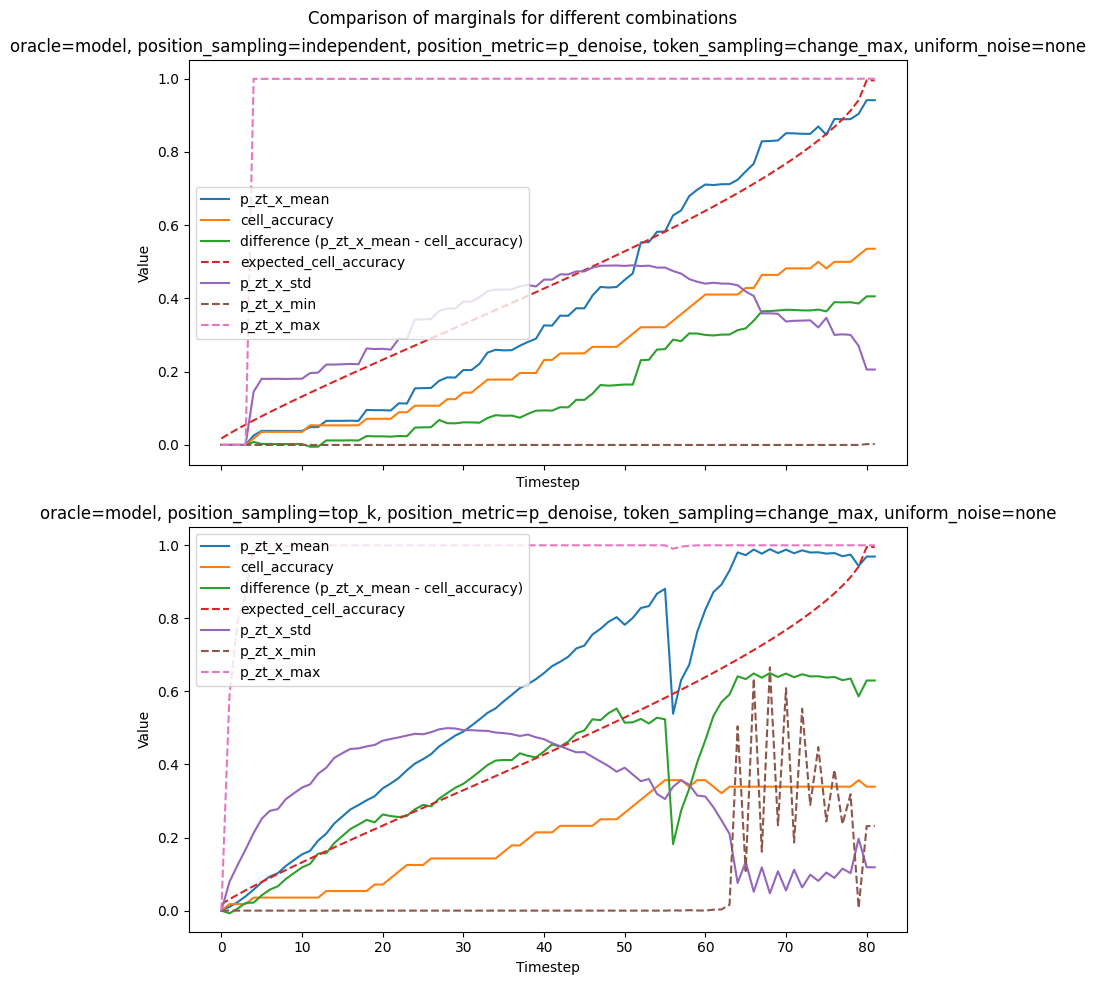

In [15]:
# Compare marginals of selected combinations

subplots_dim_0 = math.ceil(math.sqrt(num_selected_combinations))
subplots_dim_1 = math.ceil(num_selected_combinations / subplots_dim_0)
fig, axs = plt.subplots(subplots_dim_0, subplots_dim_1, figsize=(8 * subplots_dim_1, 5 * subplots_dim_0), sharex=True)
sample_index = 0

for ax, idx in zip(axs.flatten(), range(num_selected_combinations)):
    selected_combination = selected_combinations[idx]
    marginals = marginals_dict[selected_combination]
    p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()  # shape: (num_samples, num_steps)
    p_zt_x_std = marginals['p_zt_x_std'].cpu().numpy()    # shape: (num_samples, num_steps)
    p_zt_x_min = marginals['p_zt_x_min'].cpu().numpy()    # shape: (num_samples, num_steps)
    p_zt_x_max = marginals['p_zt_x_max'].cpu().numpy()    # shape: (num_samples, num_steps)
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()  # shape: (num_samples, num_steps)
    expected_cell_accuracy = marginals['expected_cell_accuracy'].cpu().numpy()  # shape: (num_steps)
    difference = p_zt_x_mean - cell_accuracy

    ax.plot(p_zt_x_mean[sample_index], label='p_zt_x_mean')
    ax.plot(cell_accuracy[sample_index], label='cell_accuracy')
    ax.plot(difference[sample_index], label='difference (p_zt_x_mean - cell_accuracy)')
    ax.plot(expected_cell_accuracy, label='expected_cell_accuracy', linestyle='--')
    ax.plot(p_zt_x_std[sample_index], label='p_zt_x_std')
    ax.plot(p_zt_x_min[sample_index], label='p_zt_x_min', linestyle='--')
    ax.plot(p_zt_x_max[sample_index], label='p_zt_x_max', linestyle='--')
    ax.set_title(f"{', '.join([f'{key}={value}' for key, value in denoise_config_dict[selected_combination].items()])}")
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()
plt.suptitle('Comparison of marginals for different combinations')
plt.tight_layout()

Sample 0, cell accuracy at last step: 0.5357142686843872
Sample 0, cell accuracy at last step: 0.3392857015132904


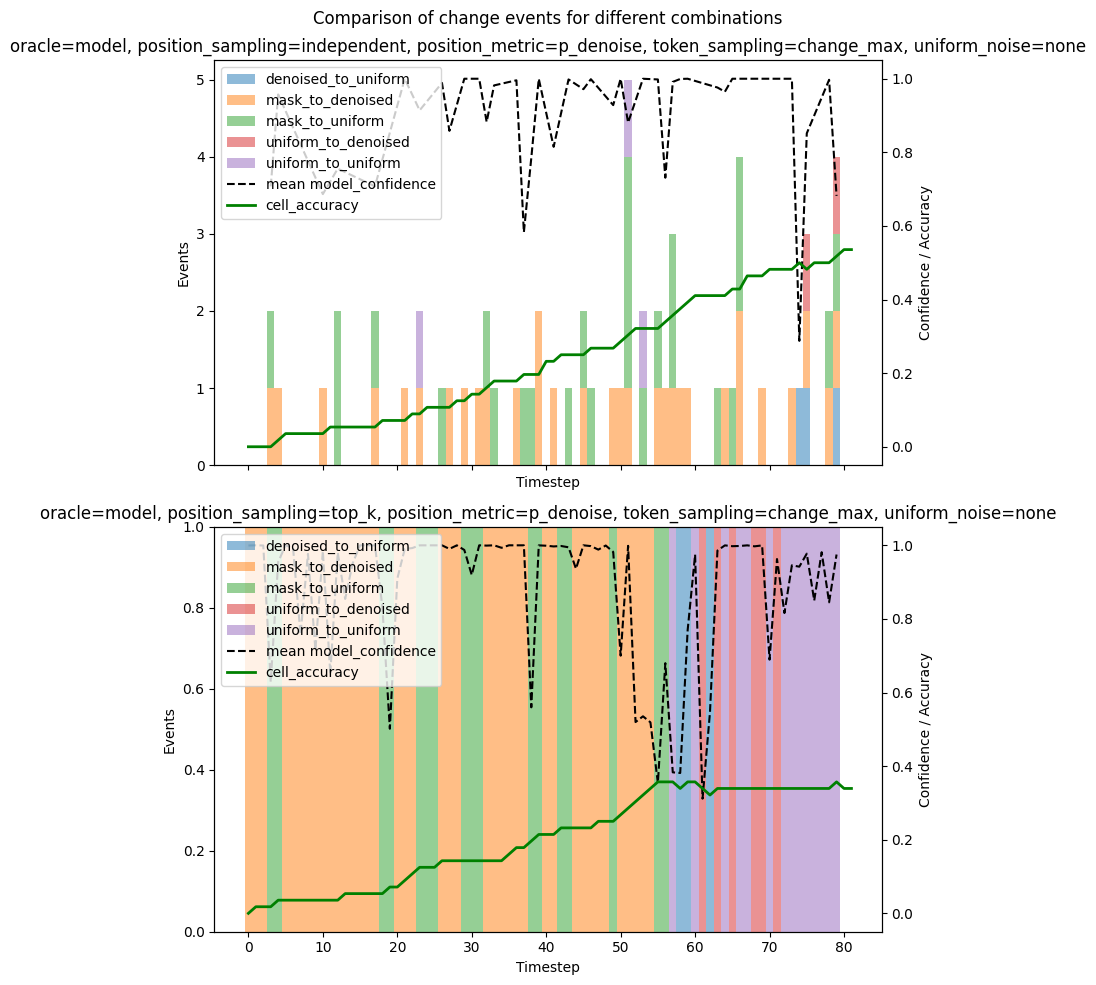

In [ ]:
# Compare change events of selected combinations

subplots_dim_0 = math.ceil(math.sqrt(num_selected_combinations))
subplots_dim_1 = math.ceil(num_selected_combinations / subplots_dim_0)
fig, axs = plt.subplots(subplots_dim_0, subplots_dim_1, figsize=(8 * subplots_dim_1, 5 * subplots_dim_0), sharex=True)
sample_index = 0

for ax, idx in zip(axs.flatten(), range(num_selected_combinations)):
    selected_combination = selected_combinations[idx]
    change_events_table = change_events_table_dict[selected_combination]
    marginals = marginals_dict[selected_combination]
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()

    sample_events = change_events_table[change_events_table['sample'] == idx]

    event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)

    bottom = None
    for event_type in event_counts.columns:
        ax.bar(event_counts.index, event_counts[event_type], bottom=bottom, 
               alpha=0.5, width=1, label=event_type)
        if bottom is None:
            bottom = event_counts[event_type]
        else:
            bottom += event_counts[event_type]

    # Create a secondary y-axis for confidence and accuracy
    ax2 = ax.twinx()

    # Plot mean model_confidence per step
    mean_conf_before = sample_events.groupby('step')['model_confidence'].mean()
    ax2.plot(mean_conf_before.index, mean_conf_before.values, color='black', label='mean model_confidence', linestyle='--')

    # Plot cell_accuracy for this sample - now using actual timestep indices
    timesteps = range(len(cell_accuracy[sample_index]))
    ax2.plot(timesteps, cell_accuracy[sample_index], color='green', label='cell_accuracy', linewidth=2)
    print(f"Sample {sample_index}, cell accuracy at last step: {cell_accuracy[sample_index, -1]}")

    ax.set_title(f"{', '.join([f'{key}={value}' for key, value in denoise_config_dict[selected_combination].items()])}")
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Events')
    ax2.set_ylabel('Confidence / Accuracy')

    # Combine legends from both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.suptitle('Comparison of change events for different combinations')
plt.tight_layout()

In [ ]:
# Scatterplot of change events: x-axis: binned model confidence (before), y-axis: 1 if new value is denoised, 0 otherwise
# maybe use different colors for different binned time steps